In [ ]:
#non-iid
#samples_local_non_iid = np.full(K, len(x) // K)

K=10
num_classes=2
samples_avg_local=6000

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
trainset = torchvision.datasets.MNIST(root='./MNIST_dataset/', train=True, download=True, transform=transform)

x, y = zip(*trainset)
x = torch.stack(list(x), dim = 0)
list_of_samples = np.full(K, len(x) // K)
y = np.array(y)

idx = [list((y==i).nonzero()[0]) for i in range(10)]   # Indices for each of ten classies

idx_localDB_non_iid = []
for i in range(K):
    types = np.random.choice(10, num_classes, replace=False)

    tmp = []
    for j in range(num_classes):
        tmp += idx[types[j]]

    idx_localDB_non_iid.append(list(np.random.choice(tmp, list_of_samples[i], replace=False)))

testset = torchvision.datasets.MNIST(root='./MNIST_dataset/', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=samples_avg_local, shuffle=False, num_workers=2)

classes = (0, 1, 2, 3, 4, 5, 6, 7, 8, 9)
print(list_of_samples) # 각 클라이언트 600개씩


100%|██████████| 9.91M/9.91M [00:04<00:00, 2.18MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 165kB/s]
100%|██████████| 1.65M/1.65M [00:06<00:00, 265kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.33MB/s]

Total clients: 10
Samples per client: [6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]



C:\Users\aloti\AppData\Local\Temp\ipykernel_49308\2826487975.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y = np.array(trainset.targets)


# 새 섹션

In [ ]:
import torch
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import torch.nn as nn
import random
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
import torch.nn.init
import torch.optim as optim
import torchvision

# 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)  # 초기화 값 설정

# 데이터 전처리
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# MNIST 데이터셋 다운로드
mnist_train = dsets.MNIST(root='MNIST_data/', train=True, transform=transform, download=True)
mnist_test = dsets.MNIST(root='MNIST_data/', train=False, transform=transform, download=True)
print(len(mnist_train))
print(len(mnist_test))

100%|██████████| 9.91M/9.91M [00:00<00:00, 37.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.18MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.45MB/s]

60000
10000


[53871, 57848, 31951, 8053, 39021, 8259, 1511, 32259, 15682, 4907, 22381, 21537, 28702, 41552, 15658, 5857, 17339, 52351, 53789, 11671, 58315, 35649, 45039, 60, 33467, 34847, 17189, 49473, 3660, 57010, 17650, 43151, 54772, 55925, 31982, 17431, 18475, 47646, 32090, 901, 5814, 15941, 15398, 45903, 46714, 51529, 31389, 23946, 1395, 15315, 39498, 58627, 53638, 16136, 22547, 6527, 860, 27759, 2040, 1216, 18200, 16679, 20918, 7876, 20221, 4286, 24837, 12266, 34307, 35748, 30291, 11959, 3930, 52874, 28696, 1434, 44662, 13326, 33190, 7793, 57889, 30761, 28847, 5318, 3852, 17127, 3920, 47803, 44976, 35934, 3418, 13620, 20995, 26334, 1343, 16611, 30167, 37622, 29927, 48067, 34964, 54885, 50177, 9222, 688, 5162, 33377, 44738, 58506, 40725, 54292, 42316, 521, 5630, 31863, 41058, 10558, 41198, 6038, 38238, 44661, 20428, 9877, 35524, 27684, 27264, 47112, 15496, 21545, 45892, 20295, 57043, 58943, 28555, 92, 3311, 52408, 26101, 27993, 10753, 12778, 33695, 49762, 43757, 333, 33235, 50448, 32172, 59987,

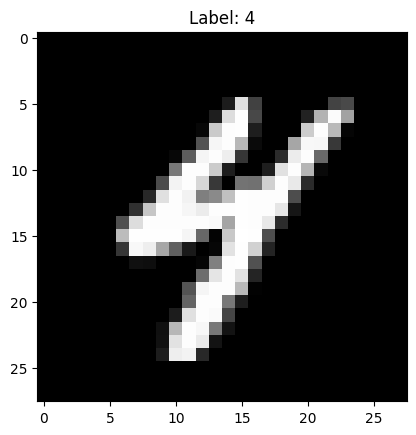

In [ ]:
# IID 데이터 생성 함수
def client_data_iid(dataset, num_clients):
    num_items = int(len(dataset) / num_clients)  # 각 클라이언트가 가져갈 데이터의 수
    dataset_index = list(range(len(dataset)))  # 전체 데이터셋의 인덱스
    random.shuffle(dataset_index)  # 인덱스 섞기
    client_datasets = []
    for i in range(num_clients):
        # 각 클라이언트에 대한 인덱스 하위 리스트 생성
        client_datasets.append(dataset_index[i * num_items:(i + 1) * num_items])  #슬라이싱으로 나누기 dataset_index를
    return client_datasets

client_dataset=client_data_iid(mnist_train,num_clients=10)
print(client_dataset[0])
print(len(client_dataset[0]))

from collections import Counter

list_of_samples=[]
def print_label_distribution(client_datasets, dataset):
    """ 각 클라이언트의 라벨 분포와 데이터의 총 개수를 출력 """
    num_clients = len(client_datasets)

    for client_id, indices in enumerate(client_datasets):
        labels = [dataset[i][1] for i in indices]  # 각 클라이언트의 인덱스를 사용하여 라벨 추출
        label_counts = Counter(labels)  # 라벨 카운트
        total_data = len(labels)  # 클라이언트가 가진 데이터의 총 개수
        list_of_samples.append(total_data)
        print(f"Client {client_id + 1} has {total_data} data points.")
        print(f"Label distribution: {dict(label_counts)}")
        print()  # 각 클라이언트 정보 간의 간격을 주기 위해 빈 줄 추가

# 클라이언트별 라벨 분포와 데이터 개수 출력
print_label_distribution(client_dataset, mnist_train)
print(list_of_samples)
print(len(list_of_samples))
image, label = mnist_train[2441]  # 이미지와 라벨 가져오기
plt.imshow(image.squeeze(), cmap='gray')  # 이미지 시각화
plt.title(f"Label: {label}")  # 라벨 표시
plt.show()

In [ ]:
#Client 만들기 클래스 말고 함수로 만들어서 해보기

batch_size=64

def Client(num_epochs, client_id, initial_weights=None): # client_id를 인자로 받음
    train_loader = DataLoader(
        dataset=Subset(mnist_train, client_dataset[client_id]), # client_id를 사용하여 Subset 생성
        batch_size=batch_size,
        shuffle=True
    )
    model = nn.Sequential(
        nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Flatten(),
        nn.Linear(7 * 7 * 64, 10, bias=True),
    ).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss().to(device)

    if initial_weights is not None:
        model.load_state_dict(initial_weights)

    for epoch in range(num_epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return model.state_dict()


In [ ]:
def evaluate_model(model, test_dataset):
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

accuracy_history=[]
for i in range(num_rounds):
    accuracy = evaluate_model(model, mnist_test)
    accuracy_history.append(accuracy)
    print(f"Round {i + 1}/{num_rounds}, Test Accuracy: {accuracy:.2f}%")

In [ ]:
#Server 만들기

num_rounds = 10
num_epochs = 2
num_clients = 10
global_weights_average = {}

model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(7 * 7 * 64, 10, bias=True),
).to(device)


for i in range(num_rounds):
    client_weights = []
    for client_id in range(num_clients):
        initial_weights=None if i==0 else global_weights_average
        state_dict = Client(num_epochs, client_id, initial_weights)
        client_weights.append(state_dict)

    global_weights_average = {
        key: torch.mean(torch.stack([client_weights[i][key] for i in range(num_clients)]), dim=0)
        for key in client_weights[0].keys()
    }
    model.load_state_dict(global_weights_average)
    accuracy_history=[]
    accuracy = evaluate_model(model, mnist_test)
    accuracy_history.append(accuracy)
    print(f"Round {i + 1}/{num_rounds}, Test Accuracy: {accuracy:.2f}%")

KeyboardInterrupt: 

In [ ]:
plt.plot(range(0,num_rounds),accuracy_history, color='blue')
plt.title('Test Accuracy vs Communication Rounds')
plt.xlabel('Communication Rounds')
plt.ylabel('Test Accuracy (%)')
plt.legend()
plt.show()

# 새 섹션

In [ ]:
import torch
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import torch.nn as nn
import random
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
import torch.nn.init
import torch.optim as optim
import torchvision
import collections
from torchvision import datasets, transforms

# 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)  # 초기화 값 설정

# 데이터 전처리
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# MNIST 데이터셋 다운로드
mnist_train = dsets.MNIST(root='MNIST_data/', train=True, transform=transform, download=True)
mnist_test = dsets.MNIST(root='MNIST_data/', train=False, transform=transform, download=True)
print(len(mnist_train))
print(len(mnist_test))

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 143MB/s]


Extracting MNIST_data/MNIST/raw/train-images-idx3-ubyte.gz to MNIST_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 37.7MB/s]


Extracting MNIST_data/MNIST/raw/train-labels-idx1-ubyte.gz to MNIST_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 95.5MB/s]


Extracting MNIST_data/MNIST/raw/t10k-images-idx3-ubyte.gz to MNIST_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 6.07MB/s]


Extracting MNIST_data/MNIST/raw/t10k-labels-idx1-ubyte.gz to MNIST_data/MNIST/raw

60000
10000


In [ ]:
#Non-IID
def split_mnist_noniid_fixed(mnist_dataset, num_clients=10, num_shards=20, seed=42):
    """
    MNIST 데이터를 Non-IID로 클라이언트에 분배하는 함수 (각 클라이언트가 정확히 2개 클래스만 가지도록 보장)
    - num_clients: 클라이언트 개수
    - num_shards: 데이터를 나눌 샤드(shard) 개수
    - seed: 랜덤 시드 고정 (재현 가능성)

    반환값:
    - client_data: 클라이언트별 데이터 인덱스 리스트 (딕셔너리 형태)
    """
    np.random.seed(seed)

    num_samples = len(mnist_dataset)
    indices = np.arange(num_samples)
    labels = np.array(mnist_dataset.targets)

    # 각 숫자(0~9)별로 데이터를 분리
    label_dict = {i: indices[labels == i] for i in range(10)}

    # 각 숫자를 2개의 샤드로 분할
    shards_per_label = num_shards // 10  # 숫자당 샤드 개수 (20개 샤드 → 10개 클래스 → 숫자당 2개 샤드)
    shards = []

    for label, idx in label_dict.items():
        np.random.shuffle(idx)  # 섞기
        shard_size = len(idx) // shards_per_label  # 각 샤드 크기
        label_shards = [idx[i * shard_size: (i + 1) * shard_size] for i in range(shards_per_label)]
        shards.extend(label_shards)

    np.random.shuffle(shards)  # 샤드를 섞음
    client_data = {i: [] for i in range(num_clients)}

    # 클라이언트에 정확히 2개 샤드 할당 (2개 숫자 보장)
    for i in range(num_clients):
        selected_shards = np.random.choice(range(len(shards)), 2, replace=False)
        for shard_idx in selected_shards:
            client_data[i].extend(shards[shard_idx])
        # 선택된 샤드 제거 (중복 방지)
        for shard_idx in sorted(selected_shards, reverse=True):
            del shards[shard_idx]

    return client_data

# MNIST 데이터 불러오기
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = dsets.MNIST(root="./data", train=True, download=True, transform=transform)

# Non-IID 데이터 생성 (각 클라이언트가 2개 숫자만 가지도록 보장)
num_clients = 10
client_data_indices = split_mnist_noniid_fixed(mnist_train, num_clients=num_clients)

# 클라이언트별 데이터 라벨 분포 확인
for client_id, indices in client_data_indices.items():
    labels = mnist_train.targets[indices]  # 해당 클라이언트의 데이터 라벨 가져오기
    label_counts = collections.Counter(labels.numpy())  # 라벨별 개수 세기
    print(f"Client {client_id}: {dict(label_counts)}")



Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 152MB/s]

Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw



Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 37.6MB/s]


...

100%|██████████| 1.65M/1.65M [00:00<00:00, 91.2MB/s]

Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw



Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 5.78MB/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Client 0: {0: 2961, 3: 3065}
Client 1: {3: 3065, 1: 3371}
Client 2: {0: 2961, 4: 2921}
Client 3: {2: 2979, 8: 2925}
Client 4: {2: 2979, 6: 2959}
Client 5: {9: 2974, 7: 3132}
Client 6: {5: 2710, 9: 2974}
Client 7: {1: 3371, 7: 3132}
Client 8: {4: 2921, 6: 2959}
Client 9: {5: 2710, 8: 2925}


In [ ]:
#Client 만들기 클래스 말고 함수로 만들어서 해보기

batch_size=64

def Client(num_epochs, client_id, initial_weights=None): # client_id를 인자로 받음
    train_loader = DataLoader(
        dataset=Subset(mnist_train, client_data_indices[client_id]), # client_id를 사용하여 Subset 생성
        batch_size=batch_size,
        shuffle=True
    )
    model = nn.Sequential(
        nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Flatten(),
        nn.Linear(7 * 7 * 64, 10, bias=True),
    ).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss().to(device)

    if initial_weights is not None:
        model.load_state_dict(initial_weights)

    for epoch in range(num_epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return model.state_dict()

In [ ]:
#Server 만들기

num_rounds = 10
num_epochs = 2
num_clients = 10
global_weights_average = {}

model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(7 * 7 * 64, 10, bias=True),
).to(device)


for i in range(num_rounds):
    client_weights = []
    for client_id in range(num_clients):
        initial_weights=None if i==0 else global_weights_average
        state_dict = Client(num_epochs, client_id, initial_weights)
        client_weights.append(state_dict)

    global_weights_average = {
        key: torch.mean(torch.stack([client_weights[i][key] for i in range(num_clients)]), dim=0)
        for key in client_weights[0].keys()
    }
    model.load_state_dict(global_weights_average)

In [ ]:
def evaluate_model(model, test_dataset):
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

accuracy_history=[]
for i in range(num_rounds):
    accuracy = evaluate_model(model, mnist_test)
    accuracy_history.append(accuracy)
    print(f"Round {i + 1}/{num_rounds}, Test Accuracy: {accuracy:.2f}%")

In [ ]:
plt.plot(range(0,num_rounds),accuracy_history, color='blue')
plt.title('Test Accuracy vs Communication Rounds')
plt.xlabel('Communication Rounds')
plt.ylabel('Test Accuracy (%)')
plt.legend()
plt.show()